In [170]:
import pandas as pd
from sklearn.impute import SimpleImputer

train = pd.read_csv('train.csv')

# 🌟 Exercise 1: Duplicate Detection and Removal
# Remove duplicate rows
train = train.drop_duplicates()
# Verify duplicates are removed
print(train.duplicated().sum())
train.info()


0
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [171]:

# 🌟 Exercise 2: Handling Missing Values
# Age, Cabin and Embarked have  missing values
# train['Age'] = train['Age'].fillna(train['Age'].mean())
num_imputer = SimpleImputer(strategy='mean')
train['Age'] = num_imputer.fit_transform(train[['Age']])
# train.head(10)

train['Cabin'] = train['Cabin'].fillna('No Cabin')
train['Embarked'] = train['Embarked'].fillna('Unknown')
train.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    str    
 11  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64
Sex     Sex_enc
male    0          577
female  1          314
Name: count, dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Title_Mme,Title_Mr,Title_Mrs,Title_Ms,Title_Rev,Title_Sir,Emb_C,Emb_Q,Emb_S,Emb_Unknown
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,0,1,0,0,0,0,0,0,1,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,0,0,1,0,0,0,1,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,0,0,0,0,0,0,0,0,1,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,0,0,1,0,0,0,0,0,1,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,0,1,0,0,0,0,0,0,1,0


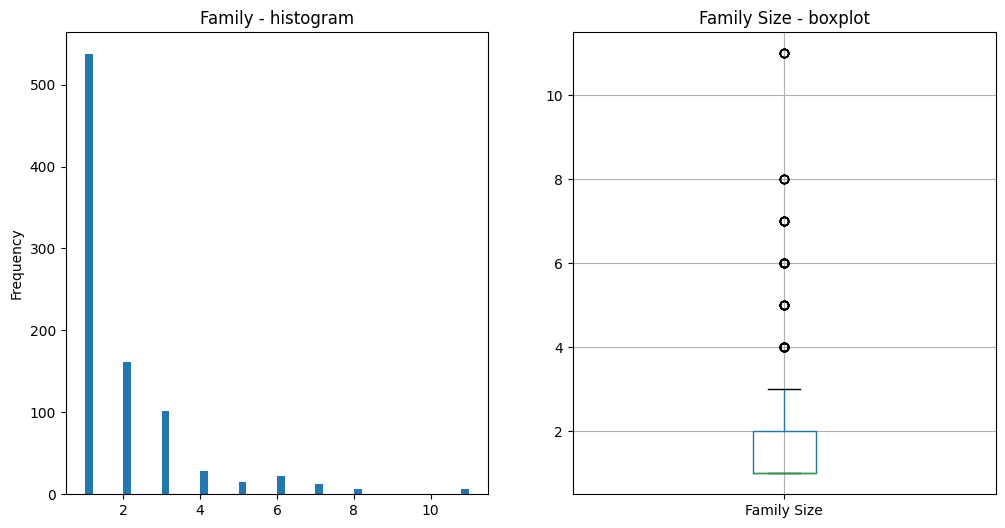

In [172]:
# 🌟 Exercise 3: Feature Engineering
import matplotlib.pyplot as plt

train['Family Size'] = train['SibSp'] + train['Parch'] + 1
train['Title'] = train['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

print(train['Title'].value_counts())

# Family Size
fig, axes = plt.subplots(1, 2, figsize=(12,6))

train['Family Size'].plot.hist(bins=50, ax=axes[0], title='Family - histogram')
train.boxplot(column='Family Size', ax=axes[1])
axes[1].set_title('Family Size - boxplot')

# # Sex: binary, label encoding
train['Sex_enc'] = train['Sex'].map({'male': 0, 'female': 1})

print(train[['Sex', 'Sex_enc']].value_counts())

# # Title and Embarked: normal with no ordinal meaning , one-hot encode
train_oh = pd.get_dummies(train, columns=['Title', 'Embarked'],prefix=['Title', 'Emb'], drop_first=False, dtype=int)
train_oh.head()

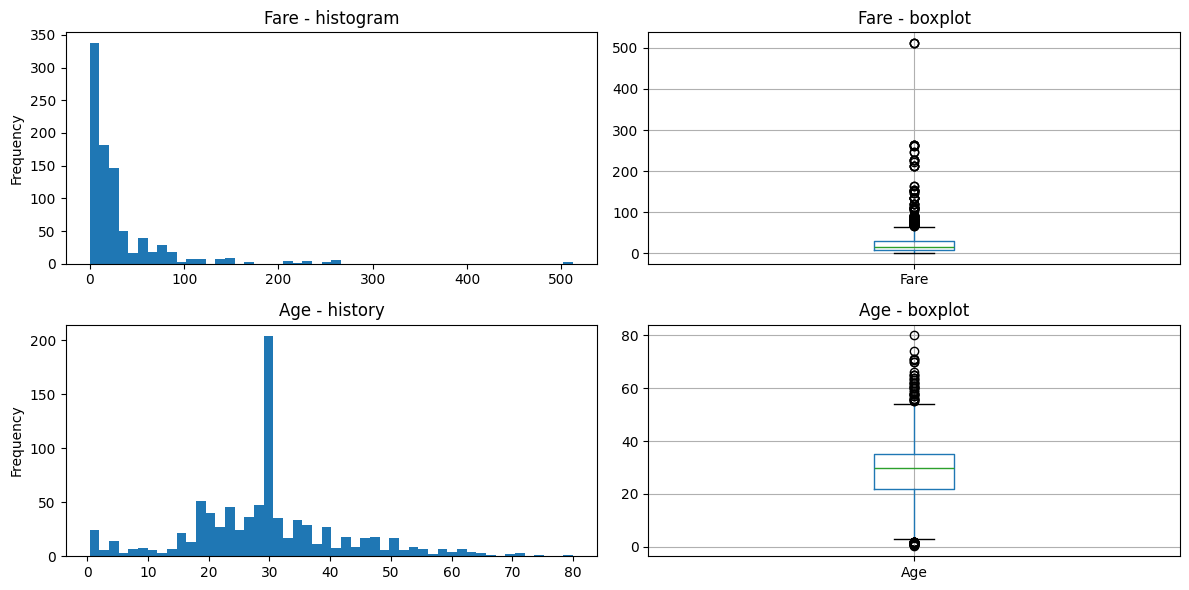

In [173]:
# 🌟 Exercise 4: Outlier Detection and Handling
#  visualize
fig, axes = plt.subplots(2, 2, figsize=(12,6))

# Fare
train['Fare'].plot.hist(bins=50, ax=axes[0,0], title='Fare - histogram')
train.boxplot(column='Fare', ax=axes[0,1])
axes[0, 1].set_title('Fare - boxplot')

# Age
train['Age'].plot.hist(bins=50, ax=axes[1,0], title='Age - history')
train.boxplot(column='Age', ax=axes[1,1])
axes[1, 1].set_title('Age - boxplot')

plt.tight_layout()
plt.show()



In [174]:
# Before analyzing:
def summary(series):
    v_min = series.min()
    v_max = series.max()
    v_mean = series.mean()
    v_std = series.std()
    return [v_min, v_max, v_mean, v_std]

fare_before = summary(train['Fare'])
age_before = summary(train['Age'])

In [175]:
# IQR detection
def iqr_outliers(series):
    
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask = (series < lower) | (series > upper)
    return mask, lower, upper

fare_mask, fare_lo, fare_hi = iqr_outliers(train['Fare'])
age_mask,  age_lo,  age_hi  = iqr_outliers(train['Age'])
print(f"Fare  — IQR bounds: [{fare_lo:.2f}, {fare_hi:.2f}]  outliers: {fare_mask.sum()}")
print(f"Age   — IQR bounds: [{age_lo:.2f},  {age_hi:.2f}]   outliers: {age_mask.sum()}")


    

Fare  — IQR bounds: [-26.72, 65.63]  outliers: 116
Age   — IQR bounds: [2.50,  54.50]   outliers: 66


In [176]:
from scipy import stats
# Z-Score detection (value-mean)/std
fare_z = abs(stats.zscore(train['Fare']))
age_z = abs(stats.zscore(train['Age']))
print(f"Fare  — Z>3 outliers: {(fare_z > 3).sum()}")
print(f"Age   — Z>3 outliers: {(age_z  > 3).sum()}")

# Cap decision:
print("\nFare quantiles:")
print(train['Fare'].quantile([0.95, 0.96, 0.97, 0.98, 0.99, 1.0]))
# Fare: strong right skew + extreme outliers → cap at 98th percentile
# (0.99 and 1.00 are identical at 512 — 0.98 gives a more meaningful cap)

fare_cap = train['Fare'].quantile(0.98)
print(fare_cap)
train['Fare'] = train['Fare'].clip(upper=fare_cap)
fare_after = summary(train['Fare'])

print("\nAge quantiles:")
print(train['Age'].quantile([0.95, 0.96, 0.97, 0.98, 0.99, 1.0]))
# Age: mild outliers (max 80), distribution is roughly normal.
# Cap top 1% to remove the single extreme value;
age_cap = train['Age'].quantile(0.99)
train['Age'] = train['Age'].clip(upper=age_cap)
age_after = summary(train['Age'])
print(train['Age'])

print(f"Age cap applied at: {age_cap:.1f}")

Fare  — Z>3 outliers: 20
Age   — Z>3 outliers: 7

Fare quantiles:
0.95    112.07915
0.96    133.99000
0.97    151.55000
0.98    211.33750
0.99    249.00622
1.00    512.32920
Name: Fare, dtype: float64
211.3375

Age quantiles:
0.95    54.0
0.96    56.0
0.97    59.0
0.98    62.0
0.99    65.0
1.00    80.0
Name: Age, dtype: float64
0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age, Length: 891, dtype: float64
Age cap applied at: 65.0


In [177]:
# Row removal is NOT used here — Titanic is small (891 rows).
# Removing rows is only appropriate when outliers are data-entry errors
# and the dataset is large enough to absorb the loss.

summary = pd.DataFrame({
    'Fare_before': fare_before,
    'Fare_after': fare_after,
    'Age_before': age_before,
    'Age_after': age_after
}, index=['min', 'max', 'mean', 'std'])
print(summary)

      Fare_before  Fare_after  Age_before  Age_after
min      0.000000    0.000000    0.420000   0.420000
max    512.329200  211.337500   80.000000  65.000000
mean    32.204208   30.678483   29.699118  29.640195
std     49.693429   39.904946   13.002015  12.820616


In [178]:
# 🌟 Exercise 5: Data Standardization and Normalization
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler_std = StandardScaler()
scaler_mm  = MinMaxScaler()

train[['AgeScaler']] = scaler_std.fit_transform(train[['Age']])
print(train['AgeScaler'].describe().round(3))

train[['FareScaler']] = scaler_mm.fit_transform(train[['Fare']])
print(train['FareScaler'].describe().round(3))


count    891.000
mean       0.000
std        1.001
min       -2.280
25%       -0.596
50%        0.005
75%        0.418
max        2.760
Name: AgeScaler, dtype: float64
count    891.000
mean       0.145
std        0.189
min        0.000
25%        0.037
50%        0.068
75%        0.147
max        1.000
Name: FareScaler, dtype: float64


In [179]:
# 🌟 Exercise 6: Feature Encoding

This exercise was already completed in Exercise 3. Here's what was done there:
Feature.  Method.                             Reason
Sex.     Label encoding → Sex_enc (0/1).      Binary
Title     One-hot → Title_Mr, Title_Mrs, ...  Nominal, 5 groups
Embarked.  One-hot → Emb_C, Emb_Q, Emb_S      Nominal, 3 ports
Pclass     None                              Already ordinal integers 1–3

In [180]:
# 🌟 Exercise 7: Data Transformation for Age Feature
bins   = [0, 12, 18, 60, 100]
labels = ['Child', 'Teen', 'Adult', 'Senior']

train['AgeGroup'] = pd.cut(train['Age'], bins=bins, labels=labels)
print(train['AgeGroup'].value_counts().sort_index())
train.head()

AgeGroup
Child      69
Teen       70
Adult     730
Senior     22
Name: count, dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family Size,Title,Sex_enc,AgeScaler,FareScaler,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,No Cabin,S,2,Mr,0,-0.596265,0.034305,Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,Mrs,1,0.652426,0.337296,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,No Cabin,S,1,Miss,1,-0.284092,0.037499,Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,Mrs,1,0.418296,0.251257,Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,No Cabin,S,1,Mr,0,0.418296,0.038091,Adult


In [181]:
train_ohe_age = pd.get_dummies(train, columns=['AgeGroup'], prefix='Age', dtype=int)

age_ohe_cols = [c for c in train_ohe_age.columns if c.startswith('Age_')]
print(age_ohe_cols)
train_ohe_age.head(10)

['Age_Child', 'Age_Teen', 'Age_Adult', 'Age_Senior']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Embarked,Family Size,Title,Sex_enc,AgeScaler,FareScaler,Age_Child,Age_Teen,Age_Adult,Age_Senior
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,...,S,2,Mr,0,-0.596265,0.034305,0,0,1,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,...,C,2,Mrs,1,0.652426,0.337296,0,0,1,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,...,S,1,Miss,1,-0.284092,0.037499,0,0,1,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,...,S,2,Mrs,1,0.418296,0.251257,0,0,1,0
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,...,S,1,Mr,0,0.418296,0.038091,0,0,1,0
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,...,Q,1,Mr,0,0.004599,0.040023,0,0,1,0
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.000000,0,0,17463,51.8625,...,S,1,Mr,0,1.901117,0.245401,0,0,1,0
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.0750,...,S,5,Master,0,-2.157129,0.099722,1,0,0,0
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.000000,0,2,347742,11.1333,...,S,3,Mrs,1,-0.206049,0.052680,0,0,1,0
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.000000,1,0,237736,30.0708,...,C,2,Mrs,1,-1.220611,0.142288,0,1,0,0


In [183]:
assert train_ohe_age[age_ohe_cols].sum(axis=1).eq(1).all()
print("✓ Every passenger assigned to exactly one age group")
print(train_ohe_age[age_ohe_cols].sum())   # group sizes


✓ Every passenger assigned to exactly one age group
Age_Child      69
Age_Teen       70
Age_Adult     730
Age_Senior     22
dtype: int64
